In [1]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

In [3]:
df = pd.read_csv("used_car_cleaned.csv")
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,Unknown,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,Unknown,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [4]:
X = df.drop("price_usd", axis=1)

In [5]:
y = df["price_usd"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
num_features = [
    "make_year",
    "mileage_kmpl",
    "engine_cc",
    "owner_count",
    "accidents_reported"
]

In [8]:
nominal_features = [
    "fuel_type",
    "brand",
    "color",
    "service_history"
]

In [9]:
binary_features = [
    "transmission",
    "insurance_valid"
]

In [10]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),

    ("nominal",
     OneHotEncoder(drop="first"),
     nominal_features),

    ("binary",
     OneHotEncoder(drop="if_binary"),
     binary_features)
])

In [11]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [12]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['make_year', 'mileage_kmpl',
                                                   'engine_cc', 'owner_count',
                                                   'accidents_reported']),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first'),
                                                  ['fuel_type', 'brand',
                                                   'color',
                                                   'service_history']),
                                                 ('binary',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['transmission',
                                                   'insurance_valid'])])),
                ('regressor', LinearRegression())])

In [13]:
y_train_pred = model.predict(X_train)

In [14]:
y_test_pred = model.predict(X_test)
y_test_pred

array([12124.39047004,  4688.22168024,  7061.90011434, ...,
       13362.16796146,  9606.13107056,  3343.09729718])

In [15]:
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mae

791.0023773132339

In [16]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mse

982113.671995924

In [17]:
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
test_rmse

np.float64(991.0164842200779)

In [18]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_r2

0.8765494410543437

In [20]:
print("=" * 50)
print("Linear Regression Performance")
print("=" * 50)

print(f"Train MAE  : {train_mae:.2f}")
print(f"Test MAE   : {test_mae:.2f}")

print()

print(f"Train MSE  : {train_mse:.2f}")
print(f"Test MSE   : {test_mse:.2f}")

print()

print(f"Train RMSE : {train_rmse:.2f}")
print(f"Test RMSE  : {test_rmse:.2f}")

print()

print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

Linear Regression Performance
Train MAE  : 797.12
Test MAE   : 791.00

Train MSE  : 1003572.37
Test MSE   : 982113.67

Train RMSE : 1001.78
Test RMSE  : 991.02

Train R²   : 0.8709
Test R²    : 0.8765


In [21]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

results.head(10)

,Actual,Predicted
0,12772.12,12124.390470
1,6177.69,4688.221680
2,6850.02,7061.900114
3,3373.18,3566.950048
4,7314.85,8034.879727
5,6970.37,7078.830142
6,9561.19,8608.354635
7,9654.64,8844.927115
8,2847.78,3952.003634
9,3879.13,4232.690031


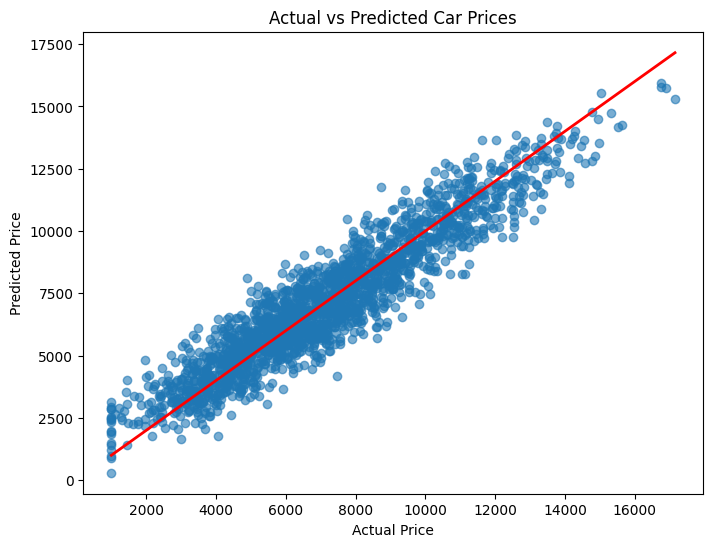

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

Observation:

• معظم النقاط تقع بالقرب من الخط الأحمر.
• يشير ذلك إلى أن النموذج يتنبأ بأسعار السيارات بدقة جيدة.
• توجد بعض الأخطاء في القيم المرتفعة، لكنها ليست كبيرة.

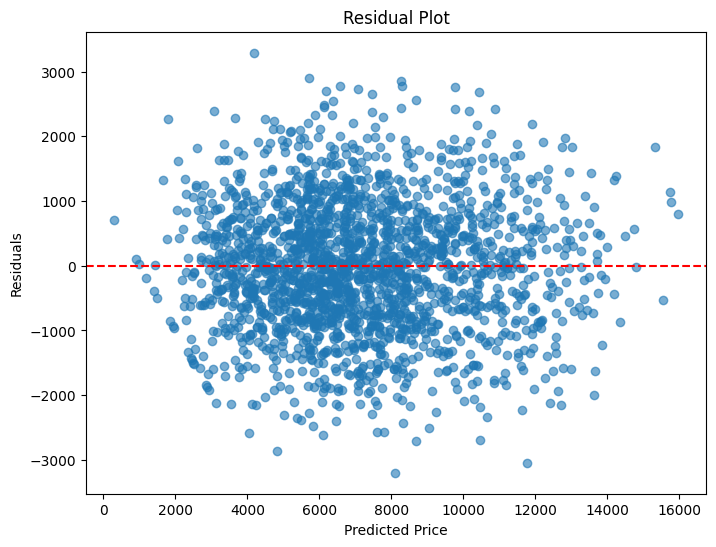

In [27]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

In [24]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient
5,nominal__fuel_type_Electric,3013.834928
2,num__engine_cc,1927.249082
0,num__make_year,1247.665688
3,num__owner_count,-694.364821
1,num__mileage_kmpl,606.045905
13,nominal__brand_Tesla,-109.776471
10,nominal__brand_Hyundai,-89.777313
8,nominal__brand_Ford,-81.393939
7,nominal__brand_Chevrolet,-80.604284
14,nominal__brand_Toyota,-68.907239


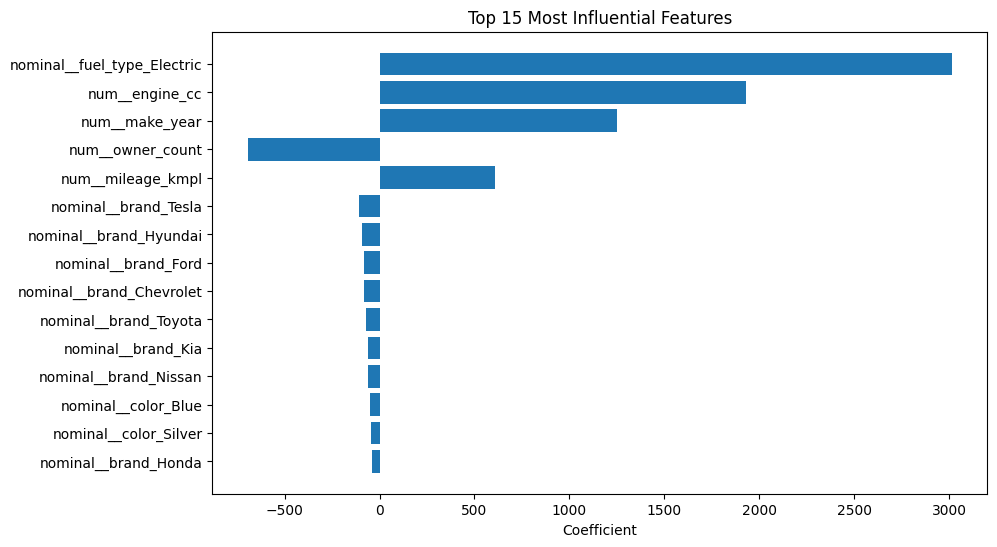

In [25]:
top_features = coef_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.title("Top 15 Most Influential Features")
plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

In [26]:
joblib.dump(model, "linear_regression_pipeline.pkl")
print("Model saved successfully.")

Model saved successfully.


# Model Evaluation

## Mean Absolute Error (MAE)

- Train MAE: **797.12**
- Test MAE: **791.00**

The model predicts car prices with an average absolute error of approximately **791 USD** on unseen data.

---

## Root Mean Squared Error (RMSE)

- Train RMSE: **1001.78**
- Test RMSE: **991.02**

The RMSE values are close for both training and testing datasets, indicating stable model performance.

---

## R² Score

- Train R²: **0.8709**
- Test R²: **0.8765**

The model explains approximately **87.65%** of the variance in car prices, which indicates strong predictive performance.

---

## Conclusion

- The model generalizes well to unseen data.
- No significant signs of overfitting or underfitting were observed.
- Linear Regression achieved strong performance and is suitable for predicting used car prices in this dataset.